In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
print("TensorFlow 版本:", tf.__version__)
print("GPU 是否可用:", tf.config.list_physical_devices('GPU'))

2026-03-11 22:08:20.021828: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-11 22:08:20.021881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-11 22:08:20.023361: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow 版本: 2.15.0
GPU 是否可用: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import tensorflow as tf

# 1. 查看所有物理设备（包含 CPU、GPU）
physical_devices = tf.config.list_physical_devices()
print("系统物理设备：", physical_devices)

# 2. 专门查看 GPU 设备
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("模型正在使用 GPU 运行，可用 GPU 列表：", gpus)
else:
    print("模型正在使用 CPU 运行，未检测到可用 GPU")

# 3. 验证具体操作的设备分配（可选）
with tf.device('/GPU:0'):
    test_tensor = tf.constant([1.0, 2.0])
print("张量运算所在设备：", test_tensor.device)  # 输出含 "/GPU:0"（用 GPU）或 "/CPU:0"（用 CPU）

系统物理设备： [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
模型正在使用 GPU 运行，可用 GPU 列表： [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
张量运算所在设备： /job:localhost/replica:0/task:0/device:GPU:0


In [4]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import os
# 添加 CUDA 库路径（替换为你的 CUDA 安装目录）
os.environ["PATH"] += ";C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v11.8\\bin"
os.environ["PATH"] += ";C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v11.8\\lib\\x64"

# 重新检测 GPU
import tensorflow as tf
print("GPU 设备列表：", tf.config.list_physical_devices('GPU'))

GPU 设备列表： [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
import tensorflow as tf
import os

# 手动注入 CUDA 路径（确保 TensorFlow 能找到底层库）
os.environ["PATH"] = "C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v11.8\\bin;" + os.environ["PATH"]

# 检查 GPU 识别
print("TensorFlow 检测到的 GPU：", tf.config.list_physical_devices('GPU'))

# 执行简单 GPU 运算（验证是否真的能用）
tf.debugging.set_log_device_placement(True)
a = tf.constant([1.0, 2.0])
b = tf.constant([3.0, 4.0])
print("运算结果：", a + b)

TensorFlow 检测到的 GPU： [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
运算结果： tf.Tensor([4. 6.], shape=(2,), dtype=float32)


检测到可用 GPU：[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]，将使用 GPU 训练
训练集形状：x_train=(60000, 28, 28, 1), y_train=(60000, 10)
测试集形状：x_test=(10000, 28, 28, 1), y_test=(10000, 10)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                            

I0000 00:00:1760607925.712104    9895 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


844/844 [==============================] - 6s 5ms/step - loss: 0.2022 - accuracy: 0.9401 - val_loss: 0.0565 - val_accuracy: 0.9835
Epoch 2/10
844/844 [==============================] - 3s 4ms/step - loss: 0.0524 - accuracy: 0.9836 - val_loss: 0.0519 - val_accuracy: 0.9845
Epoch 3/10
844/844 [==============================] - 4s 5ms/step - loss: 0.0367 - accuracy: 0.9879 - val_loss: 0.0321 - val_accuracy: 0.9910
Epoch 4/10
844/844 [==============================] - 18s 22ms/step - loss: 0.0303 - accuracy: 0.9901 - val_loss: 0.0341 - val_accuracy: 0.9903
Epoch 5/10
844/844 [==============================] - -11s -12748us/step - loss: 0.0234 - accuracy: 0.9922 - val_loss: 0.0340 - val_accuracy: 0.9908
Epoch 6/10
844/844 [==============================] - 4s 5ms/step - loss: 0.0190 - accuracy: 0.9939 - val_loss: 0.0420 - val_accuracy: 0.9890
Epoch 7/10
844/844 [==============================] - 4s 5ms/step - loss: 0.0143 - accuracy: 0.9951 - val_loss: 0.0434 - val_accuracy: 0.9902
Epoch 8/

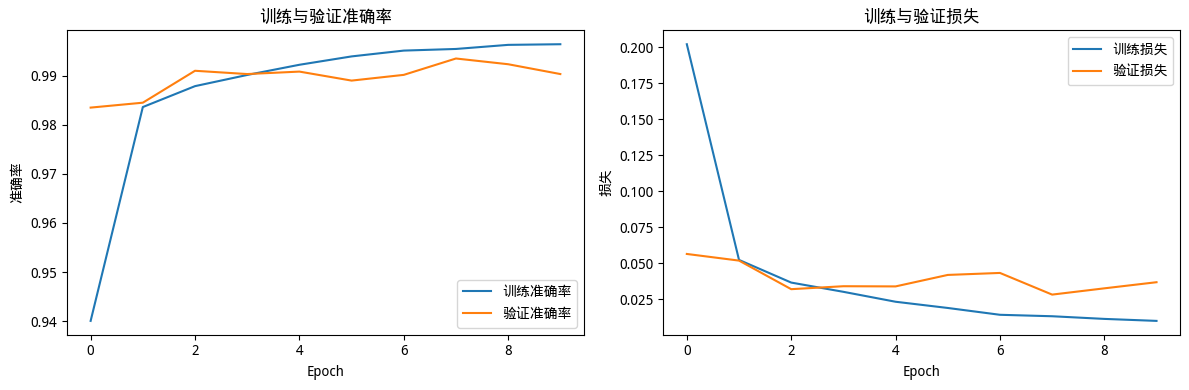

1/1 [==============================] - 0s 231ms/step


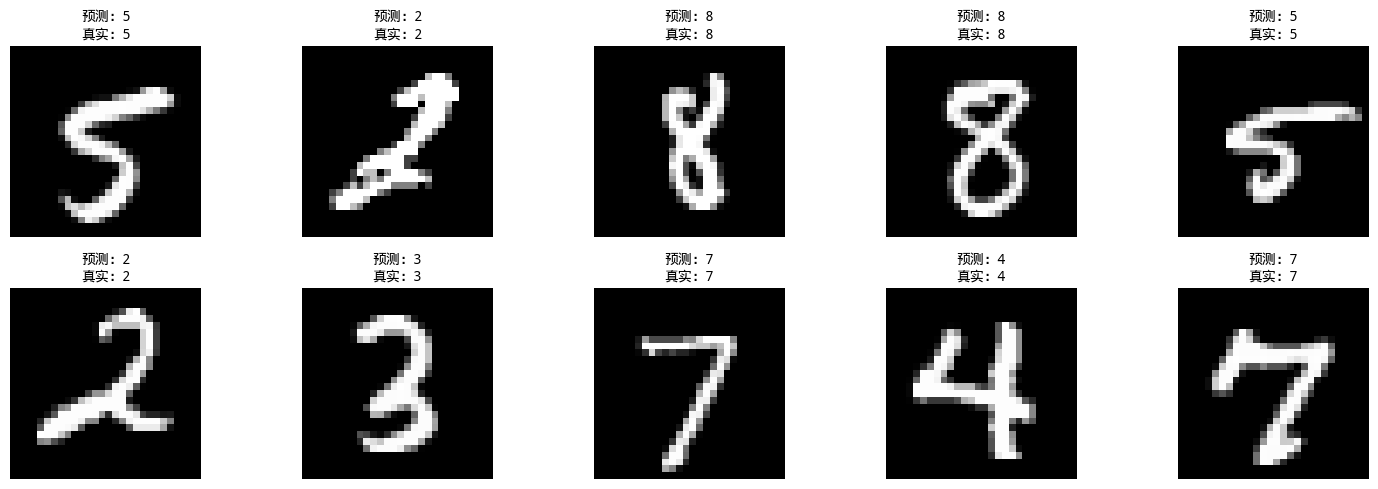

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# 1. 检查 GPU 是否可用（验证环境）
# --------------------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"检测到可用 GPU：{gpus}，将使用 GPU 训练")
else:
    print("未检测到 GPU，将使用 CPU 训练")


# --------------------------
# 2. 加载并预处理 MNIST 数据集
# --------------------------
# MNIST 是手写数字数据集（0-9），包含60000张训练图和10000张测试图，尺寸为28x28
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 数据预处理：归一化（将像素值从0-255缩放到0-1）+ 增加通道维度（CNN需要[height, width, channels]格式）
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# 标签转为独热编码（例如：数字3 → [0,0,0,1,0,0,0,0,0,0]）
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 查看数据形状
print(f"训练集形状：x_train={x_train.shape}, y_train={y_train.shape}")
print(f"测试集形状：x_test={x_test.shape}, y_test={y_test.shape}")


# --------------------------
# 3. 构建卷积神经网络（CNN）模型
# --------------------------
model = tf.keras.Sequential([
    # 第1个卷积块：卷积层+ReLU激活+池化层
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # 32个3x3卷积核
    tf.keras.layers.MaxPooling2D((2, 2)),  # 2x2最大池化，缩小特征图尺寸
    
    # 第2个卷积块
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),  # 64个3x3卷积核
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # 第3个卷积块（可选，增加网络深度）
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    
    # 展平特征图（从二维转为一维向量）
    tf.keras.layers.Flatten(),
    
    # 全连接层（分类器）
    tf.keras.layers.Dense(64, activation='relu'),  # 64个神经元
    tf.keras.layers.Dense(10, activation='softmax')  # 输出层：10个类别（0-9），softmax归一化概率
])

# 查看模型结构
model.summary()


# --------------------------
# 4. 编译模型
# --------------------------
model.compile(
    optimizer='adam',  # 优化器：Adam（自适应学习率）
    loss='categorical_crossentropy',  # 损失函数：多分类交叉熵
    metrics=['accuracy']  # 评估指标：准确率
)


# --------------------------
# 5. 训练模型
# --------------------------
history = model.fit(
    x_train, y_train,
    batch_size=64,  # 每次迭代用64个样本
    epochs=10,  # 训练10轮（遍历整个训练集10次）
    validation_split=0.1,  # 用10%的训练集作为验证集
    verbose=1  # 显示训练过程（1=进度条，0=不显示）
)


# --------------------------
# 6. 在测试集上评估模型
# --------------------------
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n测试集准确率：{test_acc:.4f}，测试集损失：{test_loss:.4f}")


# --------------------------
# 7. 可视化训练过程（准确率和损失曲线）
# --------------------------
plt.figure(figsize=(12, 4))

# 子图1：准确率曲线
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='训练准确率')
plt.plot(history.history['val_accuracy'], label='验证准确率')
plt.title('训练与验证准确率')
plt.xlabel('Epoch')
plt.ylabel('准确率')
plt.legend()

# 子图2：损失曲线
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='训练损失')
plt.plot(history.history['val_loss'], label='验证损失')
plt.title('训练与验证损失')
plt.xlabel('Epoch')
plt.ylabel('损失')
plt.legend()

plt.tight_layout()
plt.show()


# --------------------------
# 8. 随机选择测试集样本进行预测
# --------------------------
# 随机选10个测试样本
indices = np.random.choice(len(x_test), 10, replace=False)
test_samples = x_test[indices]
test_labels = y_test[indices]

# 预测
predictions = model.predict(test_samples)
predicted_labels = np.argmax(predictions, axis=1)  # 取概率最大的类别
true_labels = np.argmax(test_labels, axis=1)  # 真实标签

# 可视化预测结果
plt.figure(figsize=(15, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"预测：{predicted_labels[i]}\n真实：{true_labels[i]}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()